## 1. Library Imports & Data Load

Nothing special — pandas/numpy, statsmodels for OLS/ARIMAX, matplotlib. Using the first-differenced data (`merged_data_diff.csv`) since the raw series are non-stationary.

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('data/processed/merged_data_diff.csv', parse_dates=["date"], index_col="date")

## 2. Create Lag Features

2 AR lags on `youth_unempl`, 1 lag on each macro variable. Didn't push deeper — ~300 rows isn't much to work with and more lags just overfit.

In [24]:
## Create Lag Features 
# As youth unemployment is likely influenced by its own past values 
# and the past values of the macroeconomic indicators, 
# we will create lag features for both the target variable and the predictors.

X_cols = ["fed_funds", "cpi", "unrate", "indpro"]

# AR model
df["y_lag1"] = df["youth_unempl"].shift(1)
df["y_lag2"] = df["youth_unempl"].shift(2)

# Add lag features for X variables
for col in X_cols:
    df[f"{col}_lag1"] = df[col].shift(1)

# Drop rows with NaN values (due to lagging)
df_model = df.dropna()
print(df_model.shape)
print(df_model.columns.tolist())


(417, 12)
['youth_unempl', 'fed_funds', 'cpi', 'unrate', 'indpro', 'is_crisis', 'y_lag1', 'y_lag2', 'fed_funds_lag1', 'cpi_lag1', 'unrate_lag1', 'indpro_lag1']


## 3. Train / Test Split

Jan 2022 cutoff, roughly 80/20. The test window covers post-COVID normalization + the Fed rate hike cycle — a regime the model has never seen, so it's a harder-than-average out-of-sample test.

In [25]:
# Train/Test Split

train = df_model[df_model.index < "2022-01-01"]
test  = df_model[df_model.index >= "2022-01-01"]

print(f"Train: {train.index[0].date()} ~ {train.index[-1].date()}  ({len(train)} rows)")
print(f"Test : {test.index[0].date()}  ~ {test.index[-1].date()}  ({len(test)} rows)")

Train: 1991-03-01 ~ 2021-12-01  (370 rows)
Test : 2022-01-01  ~ 2026-01-01  (47 rows)


## 4. ADL Model Training (OLS)

HC3 robust SEs because macro data is almost never homoskedastic. Added an `is_crisis` dummy for 2008 GFC and 2020 COVID — both are obvious structural breaks that lag terms alone can't absorb.

In [26]:
# OLS model with lag features

feature_cols = ["y_lag1", "y_lag2"] + X_cols + [f"{c}_lag1" for c in X_cols] + ["is_crisis"]

X_train = sm.add_constant(train[feature_cols])
y_train = train["youth_unempl"]

model = sm.OLS(y_train, X_train).fit(cov_type="HC3")  # HC3: heteroskedasticity-robust
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           youth_unempl   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     5.644
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           2.21e-08
Time:                        15:57:28   Log-Likelihood:                -442.08
No. Observations:                 370   AIC:                             908.2
Df Residuals:                     358   BIC:                             955.1
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2626      0.282     -0.

## 5. Residual Diagnostics

Checking whether the AR lags actually cleaned up the autocorrelation:
- **ACF**: any spikes left past lag 0?
- **Q-Q plot**: fat tails = normality assumption is off
- **Durbin-Watson**: want it close to 2

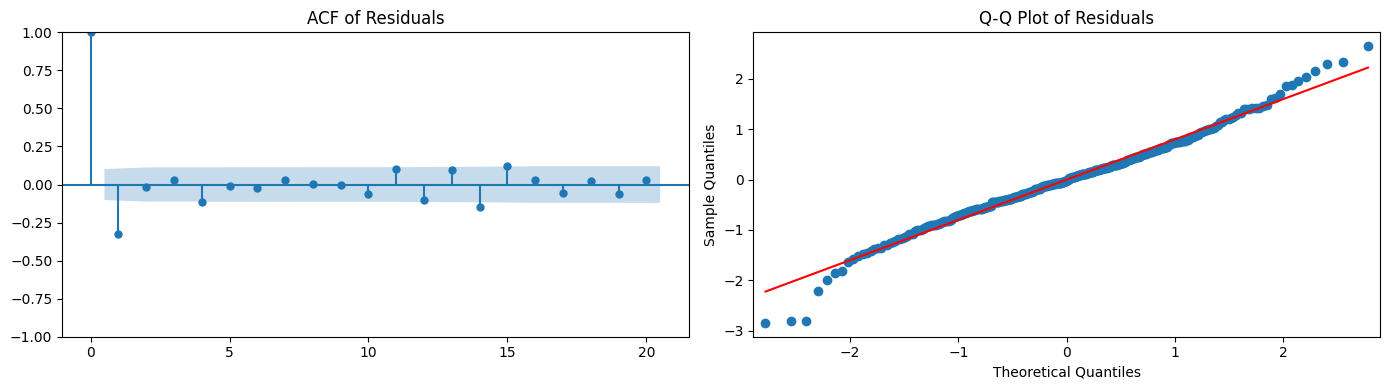

Durbin-Watson: 2.6548 (Close to 2 suggests no autocorrelation)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF of residuals
plot_acf(model.resid, lags=20, ax=axes[0])
axes[0].set_title("ACF of Residuals")

# Q-Q Plot
sm.qqplot(model.resid, line='s', ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

from statsmodels.stats.stattools import durbin_watson
print(f"Durbin-Watson: {durbin_watson(model.resid):.4f} (Close to 2 suggests no autocorrelation)")


**Results:**
- **ACF**: lag-1 (~-0.25) pokes outside the confidence band. The 2 AR terms didn't fully kill the first-order autocorrelation — looks like the model overshoots, then corrects.
- **Q-Q plot**: middle section fits fine, but the left tail goes off the line. Residuals during sharp downturns are way more extreme than a normal distribution would predict.
- **Durbin-Watson (2.65)**: above 2, consistent with the negative lag-1 autocorrelation in the ACF.

Not a disaster, but there's clearly some residual structure left. Adding more AR lags or switching to ARIMAX are the natural next steps — ARIMAX comparison is below.

## 6. Test Set Prediction & Evaluation

Predictions on the holdout set. If RMSE >> MAE, a few badly off predictions are pulling the RMSE up disproportionately.

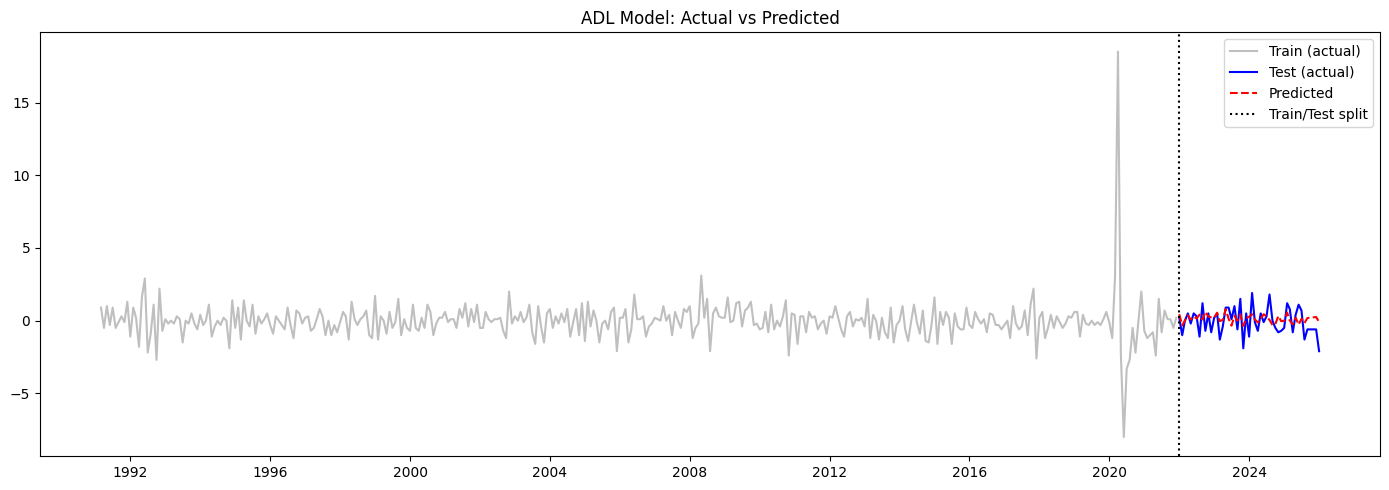

RMSE: 0.8540
MAE : 0.6847


In [28]:
X_test = sm.add_constant(test[feature_cols])
y_pred = model.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(train.index, y_train, label="Train (actual)", color="gray", alpha=0.5)
plt.plot(test.index, test["youth_unempl"], label="Test (actual)", color="blue")
plt.plot(test.index, y_pred, label="Predicted", color="red", linestyle="--")
plt.axvline(pd.Timestamp("2022-01-01"), color="black", linestyle=":", label="Train/Test split")
plt.title("ADL Model: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# RMSE / MAE
residuals = test["youth_unempl"] - y_pred
rmse = np.sqrt((residuals ** 2).mean())
mae  = residuals.abs().mean()
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

## 7. ARIMAX Model

OLS test RMSE of ~0.85 wasn't great. ARIMAX handles the AR/MA structure natively rather than through manually specified lags, so it might catch dynamics OLS missed. Grid search over (p, q) by AIC; d=0 since the data's already differenced.

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

# Grid search over (p, q) to find the best ARIMAX order by AIC
# Include same lagged X features as OLS for a fair comparison
exog_cols = X_cols + [f"{c}_lag1" for c in X_cols] + ["is_crisis"]

best_aic = np.inf
best_order = None

for p, q in product(range(4), range(4)):
    try:
        res = SARIMAX(
            train["youth_unempl"],
            exog=train[exog_cols],
            order=(p, 0, q),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = (p, 0, q)
    except Exception:
        continue

print(f"Best order: ARIMAX{best_order}  |  AIC: {best_aic:.2f}")

# Fit final model with best order
arimax_model = SARIMAX(
    train["youth_unempl"],
    exog=train[exog_cols],
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(arimax_model.summary())

/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dat

Best order: ARIMAX(2, 0, 2)  |  AIC: 850.30
                               SARIMAX Results                                
Dep. Variable:           youth_unempl   No. Observations:                  370
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -411.149
Date:                Sun, 08 Mar 2026   AIC                            850.298
Time:                        15:57:31   BIC                            904.973
Sample:                    03-01-1991   HQIC                           872.022
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
fed_funds          0.1078      0.150      0.719      0.472      -0.186       0.402
cpi                0.0455      0.080      0.568      0.570      -0.111     

/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rhkstlr/2. 코딩/Projects/Personal/data_analysis/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


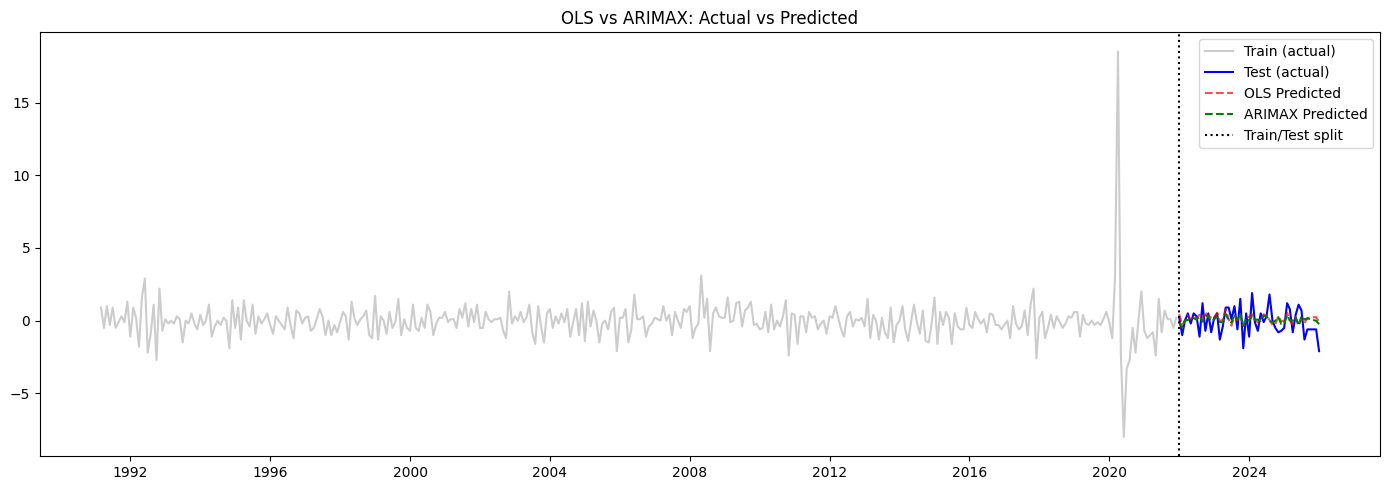

Model          RMSE      MAE
----------------------------
OLS          0.8540   0.6847
ARIMAX       0.8421   0.6853


In [30]:
# Forecast on test set
# forecast(steps) avoids the shape mismatch that predict(start, end) causes
arimax_pred = arimax_model.forecast(steps=len(test), exog=test[exog_cols])
arimax_pred.index = test.index

# OLS vs ARIMAX — side-by-side comparison plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, y_train, label="Train (actual)", color="gray", alpha=0.4)
plt.plot(test.index, test["youth_unempl"], label="Test (actual)", color="blue")
plt.plot(test.index, y_pred, label="OLS Predicted", color="red", linestyle="--", alpha=0.7)
plt.plot(test.index, arimax_pred, label="ARIMAX Predicted", color="green", linestyle="--")
plt.axvline(pd.Timestamp("2022-01-01"), color="black", linestyle=":", label="Train/Test split")
plt.title("OLS vs ARIMAX: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# RMSE / MAE — model comparison
res_arimax   = test["youth_unempl"] - arimax_pred
rmse_arimax  = np.sqrt((res_arimax ** 2).mean())
mae_arimax   = res_arimax.abs().mean()

print(f"{'Model':<10} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*28}")
print(f"{'OLS':<10} {rmse:>8.4f} {mae:>8.4f}")
print(f"{'ARIMAX':<10} {rmse_arimax:>8.4f} {mae_arimax:>8.4f}")

## 8. OLS with 3 AR Lags

Adding a 3rd AR lag and a 2nd lag for each macro variable to see if the extra terms soak up the residual autocorrelation flagged in section 5. The tradeoff is more parameters on the same ~300 rows.

In [31]:
# Extend to lag 3: y_lag3 + 2nd lag for each macro variable
df["y_lag3"] = df["youth_unempl"].shift(3)
for col in X_cols:
    df[f"{col}_lag2"] = df[col].shift(2)

df_model3 = df.dropna()

train3 = df_model3[df_model3.index < "2022-01-01"]
test3  = df_model3[df_model3.index >= "2022-01-01"]

feature_cols3 = (
    ["y_lag1", "y_lag2", "y_lag3"]
    + X_cols
    + [f"{c}_lag1" for c in X_cols]
    + [f"{c}_lag2" for c in X_cols]
    + ["is_crisis"]
)

X_train3 = sm.add_constant(train3[feature_cols3])
y_train3 = train3["youth_unempl"]

model3 = sm.OLS(y_train3, X_train3).fit(cov_type="HC3")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           youth_unempl   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     9.353
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           2.34e-19
Time:                        16:11:04   Log-Likelihood:                -400.82
No. Observations:                 369   AIC:                             835.6
Df Residuals:                     352   BIC:                             902.1
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2995      0.233     -1.

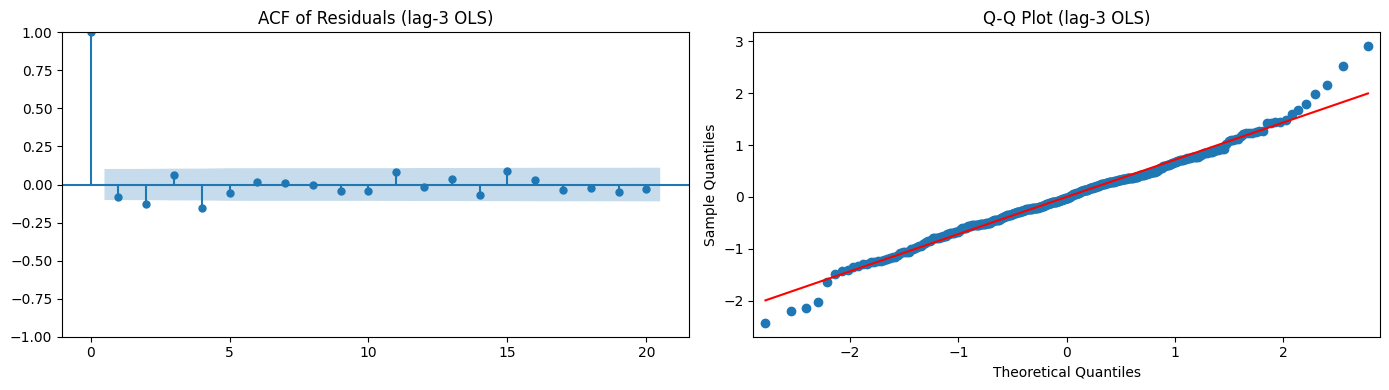

Durbin-Watson: 2.1556

Model               RMSE      MAE
---------------------------------
OLS (lag-2)       0.8540   0.6847
OLS (lag-3)       0.8485   0.6878
ARIMAX            0.8421   0.6853


In [32]:
# Test predictions + residual diagnostics vs original OLS
X_test3 = sm.add_constant(test3[feature_cols3])
y_pred3  = model3.predict(X_test3)

residuals3 = test3["youth_unempl"] - y_pred3
rmse3 = np.sqrt((residuals3 ** 2).mean())
mae3  = residuals3.abs().mean()

# ACF check
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(model3.resid, lags=20, ax=axes[0])
axes[0].set_title("ACF of Residuals (lag-3 OLS)")
sm.qqplot(model3.resid, line='s', ax=axes[1])
axes[1].set_title("Q-Q Plot (lag-3 OLS)")
plt.tight_layout()
plt.show()

from statsmodels.stats.stattools import durbin_watson
print(f"Durbin-Watson: {durbin_watson(model3.resid):.4f}")

# Model comparison
print(f"\n{'Model':<15} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*33}")
print(f"{'OLS (lag-2)':<15} {rmse:>8.4f} {mae:>8.4f}")
print(f"{'OLS (lag-3)':<15} {rmse3:>8.4f} {mae3:>8.4f}")
print(f"{'ARIMAX':<15} {rmse_arimax:>8.4f} {mae_arimax:>8.4f}")

**Results:**
- **ACF**: lag-1 spike is gone — adding the 3rd AR lag and the extra macro lags cleaned up the autocorrelation that the lag-2 model couldn't handle.
- **Durbin-Watson (2.16)**: down from 2.65, much closer to 2. Still slightly above, but not enough to worry about.
- **RMSE/MAE**: marginal improvement on RMSE (0.854 → 0.849), but MAE actually ticked up slightly (0.685 → 0.688). The extra parameters helped with the occasional large miss but didn't do much for average error.

The three models are essentially neck-and-neck on test error. At this point the bottleneck isn't the model spec — the test period (2022–) is just structurally different from anything in the training data, so there's a ceiling on how well any of these can do.